<a href="https://colab.research.google.com/github/Trangnguyen1402/AAI2025/blob/2026Fall/forecasting_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Six-Month Housing Inventory Forecast:
   month  predicted_inventory
0    102                 2184
1    103                 2178
2    104                 2173
3    105                 2167
4    106                 2161
5    107                 2155


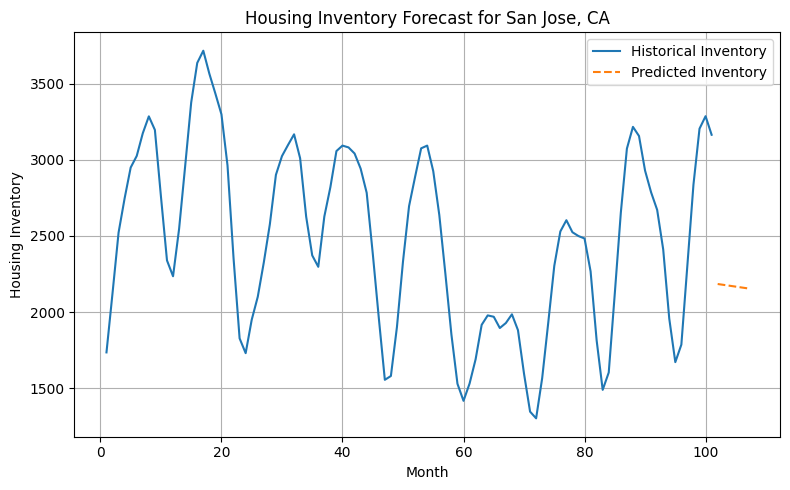

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Data source:
# Zillow Research Housing Data
# https://www.zillow.com/research/data/

# Load dataset
df = pd.read_csv(
    "Metro_invt_fs_uc_sfrcondo_sm_month (1).csv"
)

# Select one housing market
selected_region = "San Jose, CA"

region_data = df[
    df["RegionName"] == selected_region
]

# Identify the monthly columns
date_columns = [
    column for column in df.columns
    if column[:4].isdigit() and column[4] == "-"
]

# Convert Zillow's wide format into monthly format
monthly_data = region_data[date_columns].iloc[0]

monthly_data = monthly_data.reset_index()

monthly_data.columns = [
    "date",
    "inventory"
]

# Convert inventory values to numbers
monthly_data["inventory"] = pd.to_numeric(
    monthly_data["inventory"],
    errors="coerce"
)

# Remove missing values
monthly_data = monthly_data.dropna()

# Create a simple month number
monthly_data["month"] = range(
    1,
    len(monthly_data) + 1
)

# Features and target
X = monthly_data[["month"]]
y = monthly_data["inventory"]

# Train the model
model = LinearRegression()
model.fit(X, y)

# Predict the next 6 months
last_month = max(monthly_data["month"])

future_months = pd.DataFrame({
    "month": range(
        last_month + 1,
        last_month + 7
    )
})

predictions = model.predict(
    future_months[["month"]]
)

# Make sure predictions are not negative
predictions = predictions.clip(min=0)

# Display predictions
forecast = pd.DataFrame({
    "month": future_months["month"],
    "predicted_inventory": predictions.round().astype(int)
})

print("Six-Month Housing Inventory Forecast:")
print(forecast)

# Plot historical and predicted inventory
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_data["month"],
    y,
    label="Historical Inventory"
)

plt.plot(
    future_months["month"],
    predictions,
    label="Predicted Inventory",
    linestyle="--"
)

plt.xlabel("Month")
plt.ylabel("Housing Inventory")
plt.title(
    f"Housing Inventory Forecast for {selected_region}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the chart
plt.savefig("housing_inventory_forecast.png")

plt.show()

# Save predictions to a CSV file
forecast.to_csv(
    "housing_inventory_forecast.csv",
    index=False
)